In [1]:
!pip install transformers Pillow diffusers

In [2]:
from transformers import pipeline

/home/ogu/source/workshop-ki-deepdive/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sentiment = pipeline("text-classification", model="oliverguhr/german-sentiment-bert")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 17009.77it/s]


In [4]:
sentiment("Das Auto ist gar nicht mal so gut")

[{'label': 'negative', 'score': 0.9986610412597656}]

In [5]:
sentiment(["Dieser Film ist weder witzig noch intelligent", "Das Produkt ist ohne schwächen"])

[{'label': 'negative', 'score': 0.9850801825523376},
 {'label': 'positive', 'score': 0.9774584174156189}]

In [7]:
classifier = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli")
sequence_to_classify = "Angela Merkel ist eine Politikerin in Deutschland und war Vorsitzende der CDU"
candidate_labels = ["politics", "economy", "entertainment", "environment"]
output = classifier(sequence_to_classify, candidate_labels, multi_label=False)
print(output["labels"])
print(output["scores"])

/home/ogu/source/workshop-ki-deepdive/.venv/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 15987.65it/s]


['politics', 'economy', 'environment', 'entertainment']
[0.9675722718238831, 0.020081322640180588, 0.008145343512296677, 0.004201060626655817]


## Bildverarbeitung

![Bild](https://unsplash.com/photos/9YUsgVnnsTk/download?ixid=M3wxMjA3fDB8MXxhbGx8N3x8fHx8fHx8MTcxNzQyOTYxMnw&force=true&w=640)

In [8]:
from PIL import Image
import requests

image_classifier = pipeline(task="zero-shot-image-classification", model="openai/clip-vit-large-patch14-336")

# load image
image = Image.open("data/stadt.jpg")

# inference
outputs = image_classifier(image, candidate_labels=["Berlin","Dresden", "New York", "Leipzig"])
outputs

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 60358.53it/s]


[{'score': 0.9846071600914001, 'label': 'Dresden'},
 {'score': 0.014379591681063175, 'label': 'Leipzig'},
 {'score': 0.0010131108574569225, 'label': 'Berlin'},
 {'score': 8.433415388253707e-08, 'label': 'New York'}]

/home/ogu/source/workshop-ki-deepdive/.venv/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/home/ogu/source/workshop-ki-deepdive/.venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/home/ogu/source/workshop-ki-deepdive/.venv/lib/python3.14/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
100%|████

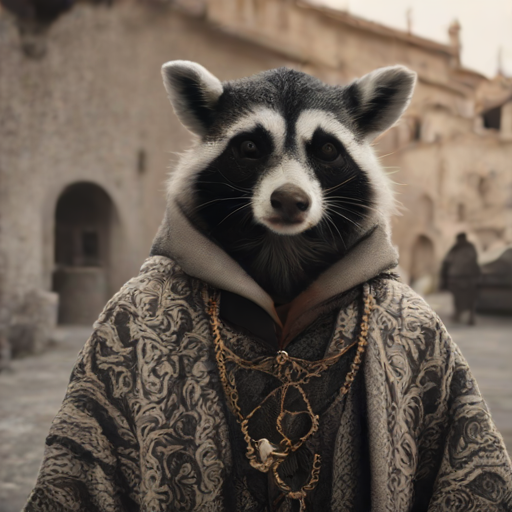

In [ ]:
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")

prompt = "A cinematic shot of a baby racoon wearing an intricate italian priest robe."

image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
image

## Audioverarbeitung

[Ich bin ein Berliner](https://www.youtube.com/watch?v=hJNM0C-7lPk&t=15s)

In [ ]:

model_id = "openai/whisper-medium"

pipe = pipeline(
    "automatic-speech-recognition",
    model=model_id,
    chunk_length_s=30,
    batch_size=16,
    device = "cuda:0"
)


result = pipe("./data/speech.mp3")

result["text"]


Loading weights: 100%|██████████| 947/947 [00:00<00:00, 20804.56it/s]
[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English,

" I am proud to come to this city as the guest of your distinguished so many years has committed Germany to democracy and freedom and progress and to come here in the company of my fellow American General Clay who has been in this city during its great moments of crisis and will come again if ever needed. 2,000 years ago, 2,000 years ago, the proudest boast was Kiwis Romanus Sum. Today, in the world of freedom, the understand or say they don't. What is the great issue between the free world and the communist world. Let them come to Berlin. There are some who say that communism is the wave of the future. Let them come to Berlin. And there are some who say in Europe and elsewhere we can work with the communists. Let them come to Berlin. And there are even a few who say that it's true that communism is an evil system, but it permits us to make economic progress. Freedom has many difficulties and democracy is not perfect but we have never had to put a wall up to keep our people in to preve

: 